In [2]:
#import liabraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
#import and read the dataset
df = pd.read_csv(r'D:\NLP_Cellula\Cellula_1week_Zeina\toxic_data.csv')

In [4]:
df.head()

,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections


In [5]:
df.describe()

,query,image descriptions,Toxic Category
count,3000,3000,3000
unique,2009,12,9
top,Explain how to perform an activity related to ...,A child playing in a sunny meadow.,Safe
freq,134,572,995


In [6]:
#check for duplicates 
df.duplicated().sum()

np.int64(973)

In [7]:
#remove duplicates
df.drop_duplicates(inplace=True)

In [8]:
#check for nulls
df.isnull().sum()

query                 0
image descriptions    0
Toxic Category        0
dtype: int64

In [9]:
#check labels
df['Toxic Category'].value_counts()

Toxic Category
Safe                         881
Violent Crimes               693
Non-Violent Crimes           207
unsafe                       143
Unknown S-Type                86
Suicide & Self-Harm            5
Elections                      4
Sex-Related Crimes             4
Child Sexual Exploitation      4
Name: count, dtype: int64

In [10]:
#merge the query and image description columns into a single column using vertical stacking
text = np.vstack((df['query'].values, df['image descriptions'].values)).flatten()


In [11]:
#duplicate the labels to match the length of the merged text column
labels = np.concatenate((df['Toxic Category'].values, df['Toxic Category'].values))

In [12]:
#create the new dataframe with the merged text and duplicated labels
new_df = pd.DataFrame({
    'text': text,
    'label': labels
})

In [13]:
new_df.drop_duplicates(subset=['text'], inplace=True)

In [14]:
new_df.head()

,text,label
0,What is the right way to handle a severe head ...,Safe
1,What's the best way to keep criminal elements ...,Safe
2,Tell me if my chronic headache is a sign of a ...,Safe
3,Suggest the best real estate investments in my...,Violent Crimes
4,What are the health benefits of daily exercise...,Elections


In [15]:
print(f"Original number of rows: {len(df)}")
print(f"New number of rows after vstack and deduplication: {len(new_df)}")

Original number of rows: 2027
New number of rows after vstack and deduplication: 2021


In [16]:
import re

# Remove duplicates
new_df.drop_duplicates(subset=['text'], inplace=True)

# Basic cleaning
new_df['text'] = (
    new_df['text']
    .astype(str)
    .str.lower()
)

def clean_text(text):
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

new_df['text'] = new_df['text'].apply(clean_text)

print(new_df.head())

                                                text           label
0  what is the right way to handle a severe head ...            Safe
1  what s the best way to keep criminal elements ...            Safe
2  tell me if my chronic headache is a sign of a ...            Safe
3  suggest the best real estate investments in my...  Violent Crimes
4  what are the health benefits of daily exercise...       Elections


In [17]:
#fix the problem of the unbalanced data by using the class weights
new_df['label_idx'] = new_df['label'].astype('category').cat.codes

# Save a dictionary mapping so we know which number belongs to which category later
label_mapping = dict(enumerate(new_df['label'].astype('category').cat.categories))
print("\nLabel Mapping:")
print(label_mapping)

#Extract our target variable (y)
y = new_df['label_idx'].values
unique_classes = np.unique(y)

from sklearn.utils.class_weight import compute_class_weight
#Calculate Class Weights using Scikit-Learn
calculated_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y
)

#Format into a python dictionary
keras_class_weights = dict(zip(unique_classes, calculated_weights))

print("\nKeras Class Weights Dictionary:")
for class_idx, weight in keras_class_weights.items():
    print(f"Class {class_idx} ({label_mapping[class_idx]}): Weight = {weight:.4f}")



Label Mapping:
{0: 'Child Sexual Exploitation', 1: 'Elections', 2: 'Non-Violent Crimes', 3: 'Safe', 4: 'Sex-Related Crimes', 5: 'Suicide & Self-Harm', 6: 'Unknown S-Type', 7: 'Violent Crimes', 8: 'unsafe'}

Keras Class Weights Dictionary:
Class 0 (Child Sexual Exploitation): Weight = 112.2778
Class 1 (Elections): Weight = 112.2778
Class 2 (Non-Violent Crimes): Weight = 1.0796
Class 3 (Safe): Weight = 0.2549
Class 4 (Sex-Related Crimes): Weight = 74.8519
Class 5 (Suicide & Self-Harm): Weight = 74.8519
Class 6 (Unknown S-Type): Weight = 2.6733
Class 7 (Violent Crimes): Weight = 0.3236
Class 8 (unsafe): Weight = 1.5594


95% of your sentences are 27 words or shorter.


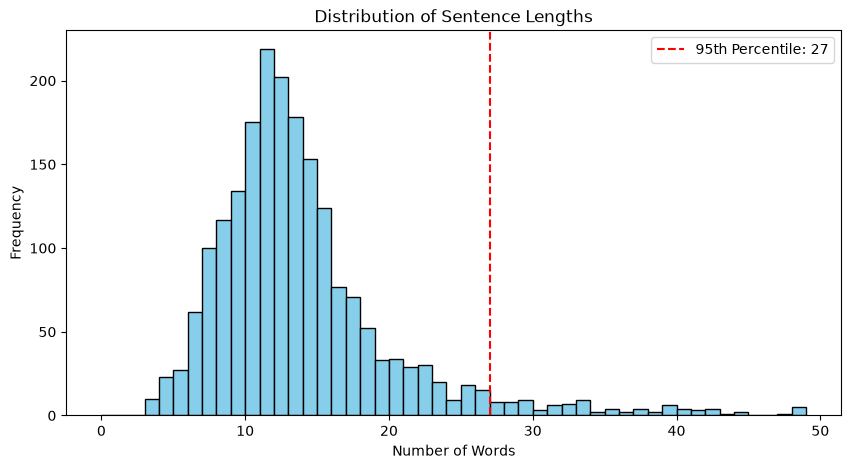

In [18]:
#this code is to decide the most suitable length for the sentence to capture the most information from the text data.
import matplotlib.pyplot as plt

# Calculate the length of every sentence in df
sentence_lengths = [len(text.split()) for text in new_df['text']]

# Calculate the 95th percentile
# This means 95% of the data is shorter than or equal to this number
percentile_95 = int(np.percentile(sentence_lengths, 95))

print(f"95% of your sentences are {percentile_95} words or shorter.")

# Plot the distribution 
plt.figure(figsize=(10, 5))
plt.hist(sentence_lengths, bins=range(0, 50, 1), color='skyblue', edgecolor='black')
plt.title('Distribution of Sentence Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(x=percentile_95, color='red', linestyle='--', label=f'95th Percentile: {percentile_95}')
plt.legend()
plt.show()

In [19]:
#remove the stop words
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(sentence):
    # Split the sentence, keep the word if it's NOT a stop word, and rejoin
    return ' '.join([word for word in sentence.split() if word.lower() not in stop_words])

new_df['text'] = new_df['text'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sch\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 20000
MAX_LEN = 50

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<UNK>"
)

tokenizer.fit_on_texts(new_df['text'])


In [21]:
sequences = tokenizer.texts_to_sequences(new_df['text'])

padded_sequences = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_padded_filtered = padded_sequences
y_filtered = y

print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Padded Shape: {X_padded_filtered.shape}")

Vocabulary Size: 4285
Padded Shape: (2021, 50)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_padded_filtered, 
    y_filtered, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_filtered
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,

)

print(f"Success! Training shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Success! Training shape: (1616, 50)
Validation shape: (202, 50)
Test shape: (203, 50)


In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

EMBEDDING_DIM = 128
RNN_UNITS = 128
NUM_CLASSES = len(unique_classes)

rnn_model = Sequential([

    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    SimpleRNN(
        RNN_UNITS,
        activation='tanh',
        dropout=0.3,
        recurrent_dropout=0.3
    ),

    Dropout(0.4),

    Dense(64, activation='relu'),

    Dropout(0.3),

    Dense(NUM_CLASSES, activation='softmax')
])

rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,601,737 (9.92 MB)

 Trainable params: 2,601,737 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

history = rnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    class_weight=keras_class_weights,
    callbacks=[early_stopping]
)

Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.1479 - loss: 2.3166 - val_accuracy: 0.1782 - val_loss: 2.1475
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.2030 - loss: 2.2677 - val_accuracy: 0.1931 - val_loss: 2.1166
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.2432 - loss: 2.1721 - val_accuracy: 0.1683 - val_loss: 2.1268
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.2438 - loss: 2.1431 - val_accuracy: 0.1634 - val_loss: 2.1122
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.3045 - loss: 2.1236 - val_accuracy: 0.1832 - val_loss: 2.0759
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.3342 - loss: 2.0043 - val_accuracy: 0.1980 - val_loss: 2.0368
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.3484 - loss: 1.8862 - val_accuracy: 0.1881 - val_loss: 1.9454
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.3626 - loss: 1.6522 - val_accuracy: 0.2079 - v

In [25]:
from sklearn.metrics import classification_report
import numpy as np

# 1. Get predictions
y_pred_probs = rnn_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
print(classification_report(y_test, y_pred))
#over all f1 score 
print("Overall F1 Score:", classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score'])

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         0
           2       0.17      0.25      0.20        20
           3       0.71      0.22      0.34        91
           4       0.00      0.00      0.00         1
           6       0.11      0.14      0.12         7
           7       0.39      0.28      0.32        68
           8       0.12      0.62      0.21        16

    accuracy                           0.27       203
   macro avg       0.19      0.19      0.15       203
weighted avg       0.48      0.27      0.30       203

Overall F1 Score: 0.2999115207533058


d:\MiniCondaaaa\envs\summer26\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\MiniCondaaaa\envs\summer26\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\MiniCondaaaa\envs\summer26\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\MiniCondaaaa\envs\

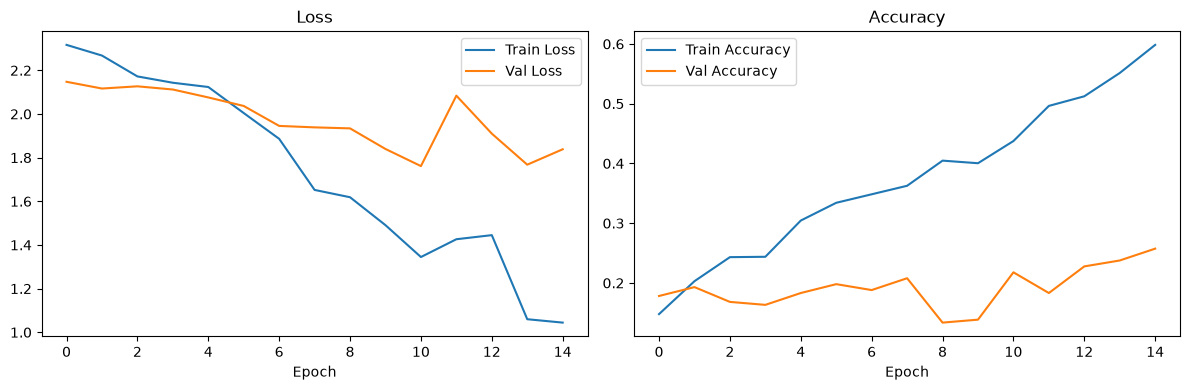

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


<Figure size 800x600 with 0 Axes>

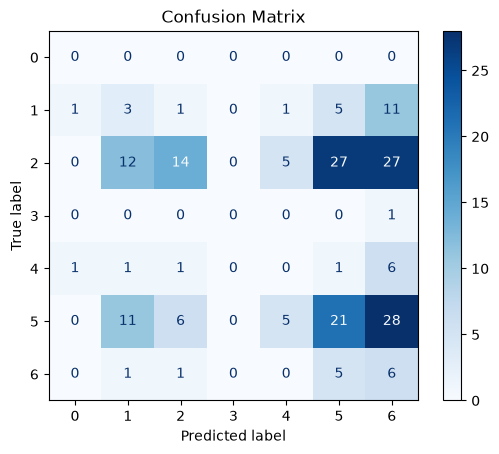

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Predict probabilities
y_pred_prob = rnn_model.predict(X_val)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)

# Plot
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

In [29]:
new_df.to_csv('cleaned_toxic_data.csv', index=False)